<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/12wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

In [6]:
# {{<video https://youtu.be/playlist?list=PLQqh36zP38-xB7p8AzMKUrEfxL0Vte-pY&si=BwVUNxT8IIPrjIcA>}}

In [7]:
import torch
import torchvision
import matplotlib.pyplot as plt

# 5. CNN의 학습원리 

## A. data 

아래의 4개의 이미지를 생각하자 .

In [49]:
img0 = torch.tensor([
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
]).reshape(1, 1, 16, 16) 
img1 = 0.1-torch.einsum('nchw->ncwh', img0.clone())
img2 = torch.zeros((1, 1, 16, 16))
for i in range(16):
    for j in range(16):
        if j <= i:  # 대각선 아래 삼각형
            img2[0, 0, i, j] = 0.1
# 빈 이미지
img3 = torch.zeros((1, 1, 16, 16))
block_size = 2
# 블록 단위로 채우기
for i in range(0, 16, block_size):
    for j in range(0, 16, block_size):
        if ((i // block_size) + (j // block_size)) % 2 == 0:
            img3[0, 0, i:i+block_size, j:j+block_size] = 0.1

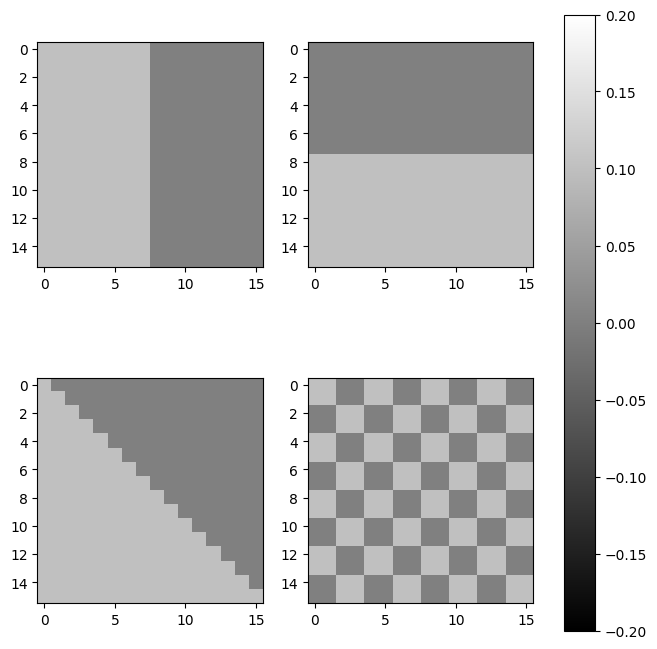

In [50]:
fig, axs = plt.subplots(2,2)
fig.set_figheight(8)
fig.set_figwidth(8)
aa = axs[0][0].imshow(img0.squeeze(),cmap="gray", vmin=-0.2, vmax=0.2)
ab = axs[0][1].imshow(img1.squeeze(),cmap="gray", vmin=-0.2, vmax=0.2)
ba = axs[1][0].imshow(img2.squeeze(),cmap="gray", vmin=-0.2, vmax=0.2)
bb = axs[1][1].imshow(img3.squeeze(),cmap="gray", vmin=-0.2, vmax=0.2)
fig.colorbar(aa, ax=axs)

In [51]:
imgs = torch.concat([img0,img1,img2,img3],axis=0)
imgs.shape

torch.Size([4, 1, 16, 16])

## B. vertical edge

In [52]:
v_conv = torch.nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=4,
    bias=False
)

In [53]:
v_conv.weight.data = torch.tensor([[[
    [ 0, 0, 0, 0],
    [ 0, 1.0, -1.0, 0],
    [0, 1.0, -1.0, 0],
    [ 0, 0, 0, 0]
]]])

> 이 `v_conv`는 좌우방향의 픽셀변화, 즉 수직 방향의 엣지(vertical edge)를 감지하는데 적절하다. 

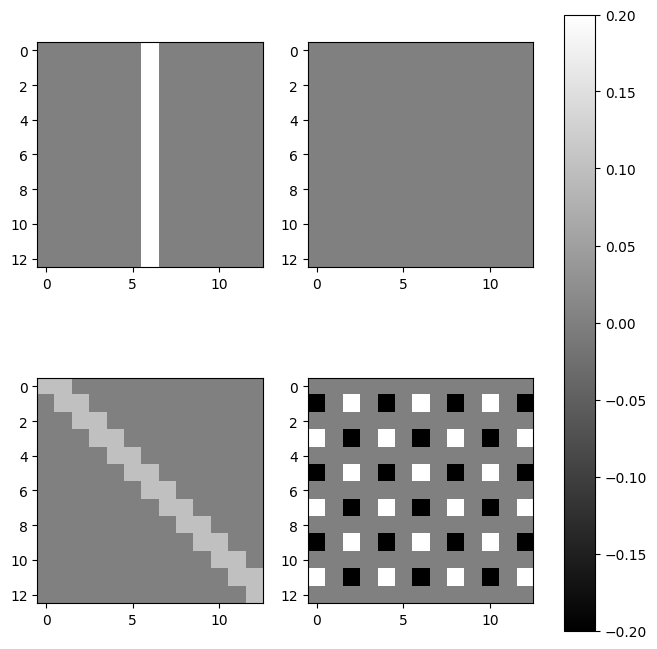

In [54]:
fig, axs = plt.subplots(2,2)
fig.set_figheight(8)
fig.set_figwidth(8)
aa = axs[0][0].imshow(v_conv(imgs)[0].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ab = axs[0][1].imshow(v_conv(imgs)[1].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ba = axs[1][0].imshow(v_conv(imgs)[2].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
bb = axs[1][1].imshow(v_conv(imgs)[3].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
fig.colorbar(aa, ax=axs)

`-` 왜 필터를 아래와 같이 설계안했을까? 

 0 -1  1  0
 0 -1  1  0
 0 -1  1  0
 0 -1  1  0

입력이미지가 아래라고 치고 stride=1이라면?

0 0 0 0 0 0  
1 1 1 0 0 0 
0 0 0 0 0 0 
3 3 3 0 0 0 
0 0 0 0 0 0 


4
4
4

만약 아래의 필터라면? 

 0  0  0  0
 0 -1 -1  0
 0  1  1  0
 0  0  0  0

2
4
2


## C. horizontal edge

In [55]:
h_conv = torch.nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=4,
    bias=False
)

In [56]:
h_conv.weight.data = torch.tensor([[[
    [ 0, 0, 0, 0],
    [ 0, -1.0, -1.0, 0],
    [0, 1.0, 1.0, 0],
    [ 0, 0, 0, 0]
]]])

> 이 `h_conv`는 위아레 방향의 픽셀변화, 즉 수평엣지(horizontal edge)를 감지하는데 적절하다. 

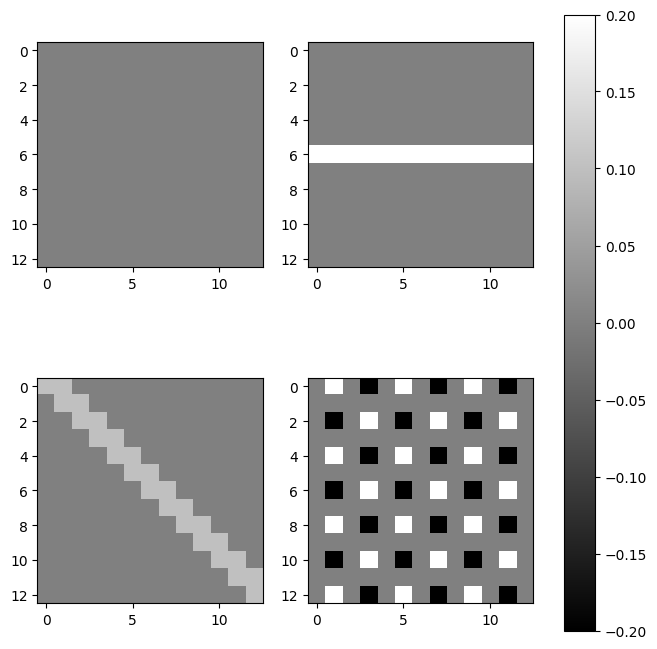

In [57]:
fig, axs = plt.subplots(2,2)
fig.set_figheight(8)
fig.set_figwidth(8)
aa = axs[0][0].imshow(h_conv(imgs)[0].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ab = axs[0][1].imshow(h_conv(imgs)[1].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ba = axs[1][0].imshow(h_conv(imgs)[2].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
bb = axs[1][1].imshow(h_conv(imgs)[3].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
fig.colorbar(aa, ax=axs)

## D. 이동평균

In [58]:
m_conv = torch.nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=4,
    bias=False
)
m_conv.weight.data = m_conv.weight.data*0 + 1/16

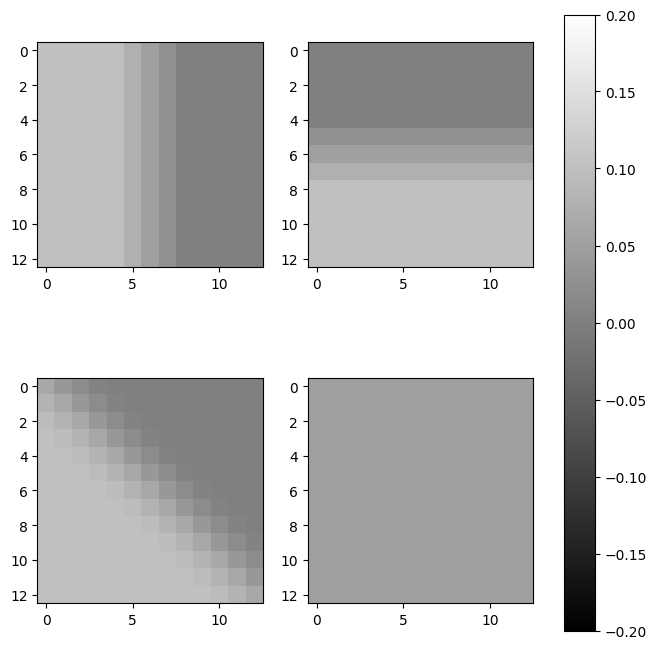

In [59]:
fig, axs = plt.subplots(2,2)
fig.set_figheight(8)
fig.set_figwidth(8)
aa = axs[0][0].imshow(m_conv(imgs)[0].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ab = axs[0][1].imshow(m_conv(imgs)[1].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
ba = axs[1][0].imshow(m_conv(imgs)[2].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
bb = axs[1][1].imshow(m_conv(imgs)[3].squeeze().data,cmap="gray", vmin=-0.2, vmax=0.2)
fig.colorbar(aa,ax=axs)

## E. (C,D,E) + relu + mp

In [60]:
relu = torch.nn.ReLU()
mp = torch.nn.MaxPool2d(kernel_size=13)

In [61]:
mp(relu(v_conv(imgs)))

tensor([[[[0.2000]]],


        [[[0.0000]]],


        [[[0.1000]]],


        [[[0.2000]]]], grad_fn=<MaxPool2DWithIndicesBackward0>)

In [62]:
mp(relu(h_conv(imgs)))

tensor([[[[0.0000]]],


        [[[0.2000]]],


        [[[0.1000]]],


        [[[0.2000]]]], grad_fn=<MaxPool2DWithIndicesBackward0>)

In [63]:
mp(relu(m_conv(imgs)))

tensor([[[[0.1000]]],


        [[[0.1000]]],


        [[[0.1000]]],


        [[[0.0500]]]], grad_fn=<MaxPool2DWithIndicesBackward0>)

## F. 대충 이런 구조

In [129]:
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1,out_channels=3,kernel_size=4,bias=False),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=13),
    torch.nn.Flatten()
)
net1[0].weight.data = torch.concat(
    [v_conv.weight.data,
     h_conv.weight.data,
     m_conv.weight.data],
     axis=0
)

In [130]:
net1[0].weight.data 

tensor([[[[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  1.0000, -1.0000,  0.0000],
          [ 0.0000,  1.0000, -1.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000]]],


        [[[ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000, -1.0000, -1.0000,  0.0000],
          [ 0.0000,  1.0000,  1.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000]]],


        [[[ 0.0625,  0.0625,  0.0625,  0.0625],
          [ 0.0625,  0.0625,  0.0625,  0.0625],
          [ 0.0625,  0.0625,  0.0625,  0.0625],
          [ 0.0625,  0.0625,  0.0625,  0.0625]]]])

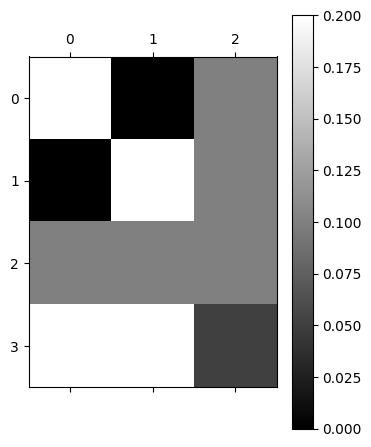

In [ ]:
plt.matshow(net1(imgs).data,cmap="gray")
plt.colorbar()ㄴㄴ

- 행을 읽는법: img0, img1, img2, img3 (|, --, \\, 체크)
- 열을 읽는법: v_conv->relu->mp, h_conv->relu->mp, m_conv->relu->mp

> 출력은 (n,3)으로 정리되어서 나온다. 이 시점부터는 더 이상 이미지가 입력이라고 생각하지 않아도 되고, 단순히 (n, 3) 크기의 숫자 데이터가 입력으로 주어진 것처럼 보면 된다.
즉 이제부터는 이 (n,3) 데이터를 입력으로 받는 신경망을 설계하면 된다.

In [169]:
net2 = torch.nn.Sequential(
    torch.nn.Linear(3,4),
    torch.nn.ReLU(),
    torch.nn.Linear(4,4)
)
net = torch.nn.Sequential(
    net1,
    net2
)

In [170]:
X = imgs 
y = torch.tensor([0,1,2,3])
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net2.parameters(),lr=0.1)
for epoch in range(30):
    ## step1
    Logits = net(X)
    ## step2
    loss = loss_fn(Logits,y)
    ## step3
    loss.backward()
    ## step4
    optimizer.step()
    optimizer.zero_grad()

In [174]:
net(X)

tensor([[ 2.4100, -3.2090,  1.0104, -1.7784],
        [-2.2607,  1.3598,  0.3514,  0.0782],
        [ 0.0746, -0.9246,  0.6809, -0.8501],
        [-2.6276, -0.9635, -1.3440,  1.2160]], grad_fn=<AddmmBackward0>)

In [175]:
net1(X)

tensor([[0.2000, 0.0000, 0.1000],
        [0.0000, 0.2000, 0.1000],
        [0.1000, 0.1000, 0.1000],
        [0.2000, 0.2000, 0.0500]], grad_fn=<ViewBackward0>)

## G. mp의 역할?

`-` 샘플이미지 

In [964]:
img = torch.zeros((1, 1, 16, 16))
triangle_size = 4
for i in range(triangle_size):
    for j in range(triangle_size):
        if j <= i:  # 아래 방향 직각삼각형 (왼쪽 위 꼭짓점 기준)
            img[0, 0, i, j] = 1.0

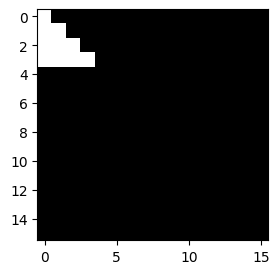

In [965]:
plt.imshow(img.squeeze(),cmap="gray")

`-` mp1 회

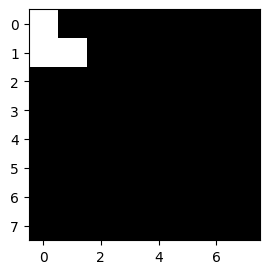

In [966]:
mp = torch.nn.MaxPool2d(kernel_size=2)
plt.imshow(mp(img).squeeze(),cmap="gray")

`-` mp 2~4회 

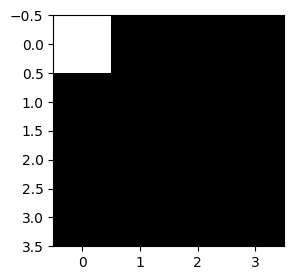

In [967]:
mp = torch.nn.MaxPool2d(kernel_size=2)
plt.imshow(mp(mp(img)).squeeze(),cmap="gray")

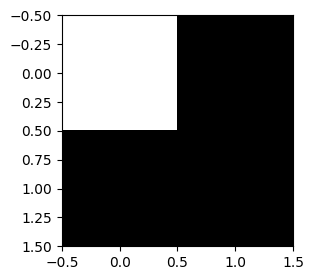

In [968]:
mp = torch.nn.MaxPool2d(kernel_size=2)
plt.imshow(mp(mp(mp(img))).squeeze(),cmap="gray")

`-` maxpooling은 이미지를 "캐리커처화" 한다고 비유할 수 있음. 디테일은 버리고, 중요한 특징만 뽑아서 과장되게 요약한다. 

### CNN의 일반적인 형태 

In [ ]:
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(...)
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(...),
    #---#
    torch.nn.Conv2d(...)
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(...),
    #---#
    ... 
)
net2 = torch.nn.Sequential(
    torch.nn.Linear(...),
    torch.nn.ReLU(),
    #---#
    torch.nn.Linear(...),
    ...
)
net = torch.nn.Sequential(net1,net2)

# 6. FashionMNIST

`-` 데이터

In [969]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
train_dataset = torch.utils.data.Subset(train_dataset, range(5000))
to_tensor = torchvision.transforms.ToTensor()
X = torch.stack([to_tensor(img) for img, lbl in train_dataset]).to("cuda:0")
y = torch.tensor([lbl for img, lbl in train_dataset])
y = torch.nn.functional.one_hot(y).float().to("cuda:0")

`-` 2d를 처리하고 flatten하는 네트워크 

In [970]:
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1,out_channels=16,kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Flatten()
).to("cuda:0")

In [971]:
net1(X).shape

torch.Size([5000, 2304])

> 출력은 (n,2304)으로 정리되어서 나온다. 이 시점부터는 더 이상 이미지가 입력이라고 생각하지 않아도 되고, 단순히 (n, 2304) 크기의 숫자 데이터가 입력으로 주어진 것처럼 보면 된다. 즉 이제부터는 이 (n,2304) 데이터를 입력으로 받는 신경망을 설계하면 된다.

`-` 1d를 처리하는 네트워크

In [972]:
net2= torch.nn.Sequential(
    torch.nn.Linear(2304,10),
).to("cuda:0")

In [973]:
net2(net1(X)).shape

torch.Size([5000, 10])

`-` 두 네트워크를 결합 

In [974]:
net = torch.nn.Sequential(
    net1,
    net2
)
net(X).shape

torch.Size([5000, 10])

`-` 최종적인 코드 

In [975]:
net = torch.nn.Sequential(
    net1,
    net2
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr=torch.optim.Adam(net.parameters())
#---#
for epoc in range(100):
    #1
    netout = net(X)
    #2
    loss = loss_fn(netout,y)
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [976]:
(net(X).argmax(axis=1) == y.argmax(axis=1)).float().mean()

tensor(0.883800, device='cuda:0')

# 7. MNIST

In [4]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,transform=torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True,transform=torchvision.transforms.ToTensor())
X,y = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=6000,shuffle=True)))
XX,yy = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=1000,shuffle=True)))

100.0%
100.0%
100.0%
100.0%


In [5]:
net = torch.nn.Sequential(
    torch.nn.Conv2d(1,32,kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Conv2d(32,32,kernel_size=3),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    #---#
    torch.nn.Linear(3200,10)
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
net.to("cuda:0")
X = X.to("cuda:0")
y = y.to("cuda:0")
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
#---#
for epoc in range(100):
    #1
    netout = net(X)
    #2
    loss = loss_fn(netout,y)
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [6]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9733, device='cuda:0')

In [7]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.9540, device='cuda:0')

In [8]:
torch.cuda.empty_cache()

# 8. CIFAR10

In [9]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,transform=torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,transform=torchvision.transforms.ToTensor())
X,y = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=10000,shuffle=True)))
XX,yy = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=2000,shuffle=True)))

100.0%


## A. 직접설계 

In [10]:
net = torch.nn.Sequential(
    torch.nn.Conv2d(3,32,kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Conv2d(32,32,kernel_size=3),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    #---#
    torch.nn.Linear(4608,10)
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
net.to("cuda:0")
X = X.to("cuda:0")
y = y.to("cuda:0")
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
#---#
for epoc in range(500):
    #1
    netout = net(X)
    #2
    loss = loss_fn(netout,y)
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [11]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.7344, device='cuda:0')

In [12]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.6080, device='cuda:0')

- 표현력자체에 문제가 있어보임

In [13]:
torch.cuda.empty_cache()

## B. 알렉스넷? 

![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Comparison_image_neural_networks.svg/960px-Comparison_image_neural_networks.svg.png)

In [14]:
img = torch.zeros(1,3*224*224).reshape(1,3,224,224)
img.shape

torch.Size([1, 3, 224, 224])

In [15]:
net = torch.nn.Sequential(
    torch.nn.Conv2d(3,96,kernel_size=(11,11),stride=4),
    torch.nn.ReLU(),    
    torch.nn.MaxPool2d((3,3),stride=2), # default stride는 3
    torch.nn.Conv2d(96,256,kernel_size=(5,5),padding=2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d((3,3),stride=2), # default stride는 3
    torch.nn.Conv2d(256,384,kernel_size=(3,3),padding=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(384,384,kernel_size=(3,3),padding=1),
    torch.nn.ReLU(),    
    torch.nn.Conv2d(384,256,kernel_size=(3,3),padding=1),
    torch.nn.ReLU(),    
    torch.nn.MaxPool2d((3,3),stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(6400,4096),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(4096,4096),        
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),    
    torch.nn.Linear(4096,1000),
)

## C. 알렉스넷으로 ImageNet 적합

In [16]:
net[-1] = torch.nn.Linear(4096,10)

In [17]:
img = torch.randn(1,3,32,32)

In [18]:
net(img)

RuntimeError: Given input size: (256x2x2). Calculated output size: (256x0x0). Output size is too small

In [19]:
net[:5](img).shape

torch.Size([1, 256, 2, 2])

In [20]:
net[5]

MaxPool2d(kernel_size=(3, 3), stride=2, padding=0, dilation=1, ceil_mode=False)

실패 ㅠㅠ 

## D. renset18

`-` res: <https://arxiv.org/pdf/1512.03385>

In [21]:
net = torchvision.models.resnet18()
# net 

In [22]:
net.fc = torch.nn.Linear(512,10)

In [23]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
net.to("cuda:0")
X = X.to("cuda:0")
y = y.to("cuda:0")
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
#---#
for epoc in range(500):
    #1
    netout = net(X)
    #2
    loss = loss_fn(netout,y)
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [30]:
net.eval()
print((net(X).argmax(axis=1) == y).float().mean())
print((net(XX).argmax(axis=1) == yy).float().mean())

tensor(1., device='cuda:0')
tensor(0.5930, device='cuda:0')


- 오버피팅이 있어보긴하지만 표현력자체는 올라감

In [31]:
torch.cuda.empty_cache()

## E. resnet18, pretrained=True

`-` 아이디어: 하나를 잘하는 모델은 다른것도 잘하지 않을까? <-- transfer learning 

In [32]:
net = torchvision.models.resnet18(pretrained=True) # 아키텍처 + 학습된 가중치까지 
net.fc = torch.nn.Linear(512,10)

/home/cgb3/anaconda3/envs/dl2025/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cgb3/anaconda3/envs/dl2025/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [33]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
net.to("cuda:0")
X = X.to("cuda:0")
y = y.to("cuda:0")
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
#---#
for epoc in range(500):
    #1
    netout = net(X)
    #2
    loss = loss_fn(netout,y)
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [34]:
net.eval()
print((net(X).argmax(axis=1) == y).float().mean())
print((net(XX).argmax(axis=1) == yy).float().mean())

tensor(1., device='cuda:0')
tensor(0.8050, device='cuda:0')


- 잘함 (오버피팅은 여전히 있음) 

In [35]:
torch.cuda.empty_cache()